# Random Forest — Classificação do Estado do Tabuleiro

Treina em `train.csv`, ajusta hiperparâmetros via `GridSearchCV` (cv=5 sobre o treino), valida em `val.csv` e reporta o desempenho final em `test.csv`.


## 1. Imports e Carregamento dos Splits


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

print("Carregando splits físicos...")
df_train = pd.read_csv('../../data/splits/train.csv')
df_val   = pd.read_csv('../../data/splits/val.csv')
df_test  = pd.read_csv('../../data/splits/test.csv')

X_train, y_train_raw = df_train.drop('classe', axis=1), df_train['classe']
X_val,   y_val_raw   = df_val.drop('classe', axis=1),   df_val['classe']
X_test,  y_test_raw  = df_test.drop('classe', axis=1),  df_test['classe']

le = LabelEncoder().fit(y_train_raw)
y_train = le.transform(y_train_raw)
y_val   = le.transform(y_val_raw)
y_test  = le.transform(y_test_raw)

print(f"Treino:    {len(X_train):4d} amostras")
print(f"Validação: {len(X_val):4d} amostras")
print(f"Teste:     {len(X_test):4d} amostras")
print(f"\nClasses: {list(le.classes_)}")


Carregando splits físicos...
Treino:    1119 amostras
Validação:  241 amostras
Teste:      240 amostras

Classes: ['Empate', 'O venceu', 'Tem jogo', 'X venceu']


## 2. Busca de Hiperparâmetros (GridSearchCV no Treino)


In [2]:
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
    'class_weight':      ['balanced', None],
}

rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_base, param_grid=param_grid,
    cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1,
)

print("Iniciando GridSearchCV...")
grid_search.fit(X_train, y_train)

print("\nMelhores parâmetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1 (CV): {grid_search.best_score_:.4f}")


Iniciando GridSearchCV...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Melhores parâmetros encontrados:
  class_weight: None
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 100

Melhor F1 (CV): 0.8988


## 3. Treinamento do Modelo Final


In [3]:
rf_model = RandomForestClassifier(**grid_search.best_params_, random_state=42)
rf_model.fit(X_train, y_train)
print("Modelo final treinado.")


Modelo final treinado.


## 4. Avaliação no Conjunto de Validação


=== VALIDAÇÃO ===
              precision    recall  f1-score   support

      Empate       0.50      0.20      0.29         5
    O venceu       0.86      0.79      0.83        48
    Tem jogo       0.87      0.89      0.88        94
    X venceu       0.96      1.00      0.98        94

    accuracy                           0.90       241
   macro avg       0.80      0.72      0.74       241
weighted avg       0.89      0.90      0.90       241

Acurácia no Treino:    1.0000
Acurácia na Validação: 0.9004

⚠️  Diferença > 5pp entre treino e validação — possível overfitting.


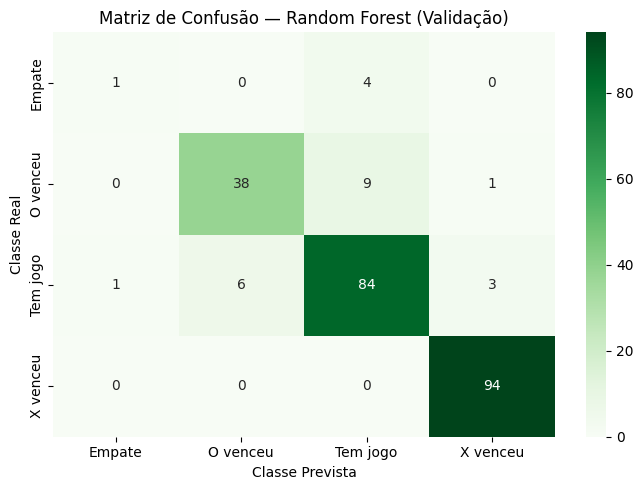

In [4]:
y_val_pred = rf_model.predict(X_val)

print("=== VALIDAÇÃO ===")
print(classification_report(
    le.inverse_transform(y_val),
    le.inverse_transform(y_val_pred),
    zero_division=0,
))

acc_treino = rf_model.score(X_train, y_train)
acc_val    = rf_model.score(X_val,   y_val)
print(f"Acurácia no Treino:    {acc_treino:.4f}")
print(f"Acurácia na Validação: {acc_val:.4f}")
if acc_treino - acc_val > 0.05:
    print("\n⚠️  Diferença > 5pp entre treino e validação — possível overfitting.")
else:
    print("\n✅  Diferença treino/validação dentro do esperado.")

plt.figure(figsize=(7, 5))
cm_val = confusion_matrix(le.inverse_transform(y_val), le.inverse_transform(y_val_pred), labels=le.classes_)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão — Random Forest (Validação)')
plt.ylabel('Classe Real'); plt.xlabel('Classe Prevista')
plt.tight_layout(); plt.show()


## 5. Avaliação Final no Conjunto de Teste


=== TESTE ===
              precision    recall  f1-score   support

      Empate       0.00      0.00      0.00         5
    O venceu       0.90      0.81      0.85        47
    Tem jogo       0.88      0.89      0.88        94
    X venceu       0.95      1.00      0.97        94

    accuracy                           0.90       240
   macro avg       0.68      0.68      0.68       240
weighted avg       0.89      0.90      0.90       240

Acurácia no Teste: 0.9000


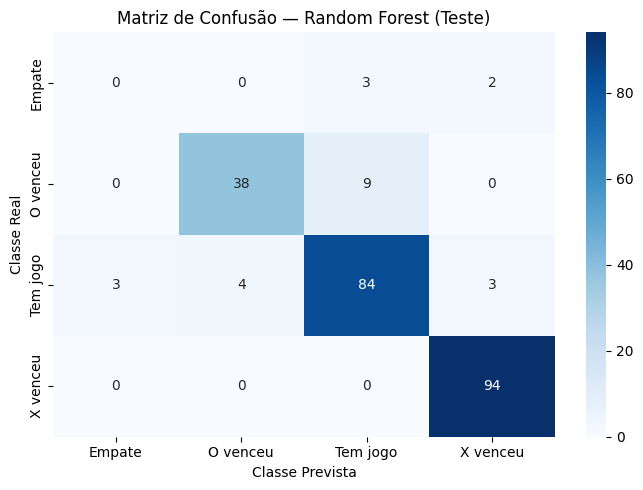

In [5]:
y_test_pred = rf_model.predict(X_test)

print("=== TESTE ===")
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_test_pred),
    zero_division=0,
))

acc_teste = rf_model.score(X_test, y_test)
print(f"Acurácia no Teste: {acc_teste:.4f}")

plt.figure(figsize=(7, 5))
cm_test = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_test_pred), labels=le.classes_)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão — Random Forest (Teste)')
plt.ylabel('Classe Real'); plt.xlabel('Classe Prevista')
plt.tight_layout(); plt.show()


## 6. Importância das Features


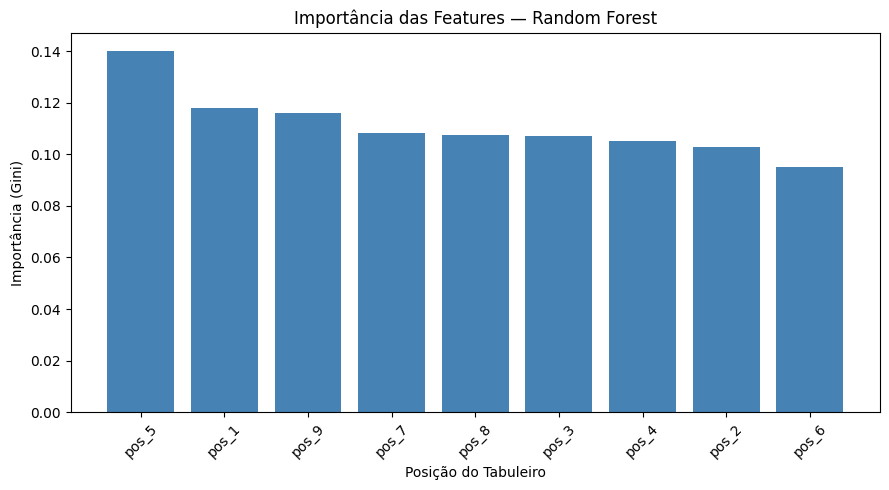


Importância por posição (ordenada):
  pos_5: 0.1401
  pos_1: 0.1181
  pos_9: 0.1158
  pos_7: 0.1083
  pos_8: 0.1074
  pos_3: 0.1071
  pos_4: 0.1052
  pos_2: 0.1029
  pos_6: 0.0951


In [6]:
importancias = rf_model.feature_importances_
features = X_train.columns.tolist()
indices_ordenados = np.argsort(importancias)[::-1]

plt.figure(figsize=(9, 5))
plt.bar([features[i] for i in indices_ordenados],
        importancias[indices_ordenados], color='steelblue')
plt.title('Importância das Features — Random Forest')
plt.xlabel('Posição do Tabuleiro'); plt.ylabel('Importância (Gini)')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print("\nImportância por posição (ordenada):")
for i in indices_ordenados:
    print(f"  {features[i]}: {importancias[i]:.4f}")


## 7. Persistência do Modelo


In [7]:
os.makedirs('../../models/RandomForest', exist_ok=True)
joblib.dump(rf_model, '../../models/RandomForest/rf_model.pkl')
joblib.dump(le,       '../../models/RandomForest/rf_label_encoder.pkl')
print("Modelo e Encoder salvos com sucesso!")


Modelo e Encoder salvos com sucesso!
